# Fine tune with Efficientnet

In [ ]:
!pip install keras_cv tensorflow_io

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 60.3 MB/s eta 0:00:00


In [ ]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
print("tensorflow:", tf.__version__)
import keras_cv
print("keras_cv:", keras_cv.__version__)
import tensorflow_io as tfio
print("tfio:", tfio.__version__)
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

tensorflow: 2.18.0
keras_cv: 0.9.0
tfio: 0.37.1


/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl8str_util8EndsWithESt17basic_string_viewIcSt11char_traitsIcEES4_']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/usr/local/lib/python3.11/dist-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZN3tsl8str_util9LowercaseB5cxx11ESt17basic_s

Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/images_spectograms /content/

In [ ]:
def obtener_spectogramas(ruta_base):
    data = []

    # Se listan las carpetas dentro de ruta_base
    image_db = os.listdir(ruta_base)
    image_db.sort()
    for i in image_db:
        ruta_db = os.path.join(ruta_base, i)
        #print("Procesando:", ruta_db)
        # Solo procesar si es un directorio
        if os.path.isdir(ruta_db):
            for img in os.listdir(ruta_db):
                ruta_img = os.path.join(ruta_db, img)
                # Verificar que sea un archivo (opcional)
                if os.path.isfile(ruta_img):
                    data.append({
                        "label": i,  # Se usa el nombre de la carpeta como etiqueta
                        "image_path": ruta_img
                    })
    return pd.DataFrame(data)

ruta_base = "/content/images_spectograms"
df = obtener_spectogramas(ruta_base)
print(df.shape)
df.head()

(269548, 2)


,label,image_path
0,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
1,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
2,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
3,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
4,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...


In [ ]:
df['label'].nunique()

667

In [ ]:
df.to_csv('/content/paths_spectograms.csv', index=False)

In [ ]:
strategy = tf.distribute.MirroredStrategy()
print("Strategy:", strategy)
print("Number of replicas:", strategy.num_replicas_in_sync)

Strategy: <tensorflow.python.distribute.mirrored_strategy.MirroredStrategy object at 0x791bb4a98390>
Number of replicas: 1


In [ ]:
sorted(tf.config.list_logical_devices())

[LogicalDevice(name='/device:CPU:0', device_type='CPU'),
 LogicalDevice(name='/device:GPU:0', device_type='GPU')]

# Config

In [ ]:
from typing import Tuple
from pydantic import BaseModel

class Config(BaseModel):
    ## general
    run_ts: str = datetime.now().strftime("%Y-%d-%m %H:%M:%S")
    debug: bool = False
    model_name: str = "ResNet152V2"
    test_size: float = 0.3
    seed: int = 42
    fit_verbose: int = 1

    ## data
    dataset_dir: str = "/content/paths_spectograms.csv"
    path_data: str = "/content/paths_spectograms.csv"
    label: str = "label"
    n_label: int = 667
    img_size: Tuple[int, int] = (128, 256)
    channels: int = 1
    img_shape: Tuple[int, int, int] = (*img_size, channels)

    ## model
    base_model_weights: str = "imagenet"
    dropout: float = 0.20

    ## training
    label_smoothing: float = 0.05
    shuffle_size: int = 1028
    steps_per_epoch: int = 500
    batch_size: int = 64
    valid_batch_size: int = batch_size
    epochs: int = 200
    patience: int = 9
    monitor: str = "val_loss"  # val_loss
    monitor_mode: str = "auto"
    lr: float = 1e-4

    ## aug
    aug_proba: float = 0.8

# Crear una instancia de la configuración
cfg = Config()
cfg.dict()

<ipython-input-10-a24aab7f8dd3>:43: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  cfg.dict()


{'run_ts': '2025-07-03 15:34:21',
 'debug': False,
 'model_name': 'ResNet152V2',
 'test_size': 0.3,
 'seed': 42,
 'fit_verbose': 1,
 'dataset_dir': '/content/paths_spectograms.csv',
 'path_data': '/content/paths_spectograms.csv',
 'label': 'label',
 'n_label': 667,
 'img_size': (128, 256),
 'channels': 1,
 'img_shape': (128, 256, 1),
 'base_model_weights': 'imagenet',
 'dropout': 0.2,
 'label_smoothing': 0.05,
 'shuffle_size': 1028,
 'steps_per_epoch': 500,
 'batch_size': 64,
 'valid_batch_size': 64,
 'epochs': 200,
 'patience': 9,
 'monitor': 'val_loss',
 'monitor_mode': 'auto',
 'lr': 0.0001,
 'aug_proba': 0.8}

# Preparation

## Load data

In [ ]:
tf.keras.backend.clear_session()

In [ ]:
data = pd.read_csv(cfg.path_data)
data["path_img"] = data["image_path"]
if cfg.debug:
    data = data.iloc[:1000]
data.sample(6)
data.shape

(269548, 3)

## Dataset

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def show_img_stats(img):
    if isinstance(img, tf.Tensor):
        print((img.shape, img.dtype, img.numpy().min(), img.numpy().max()))
    elif isinstance(img, np.array):
        print((img.shape, img.dtype, img.min(), img.max()))
    else:
        print(f"unexpected type: {type(img)}")

def read_image(path_img):
    try:
        img_data = tf.io.read_file(path_img)
        img = tf.io.decode_jpeg(img_data, channels=cfg.channels)
        img = tf.image.resize(img, cfg.img_size)
        img = tf.cast(img, tf.float32)
        return img
    except tf.errors.InvalidArgumentError:
        return None


from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
label_encoder.fit(data.label)

def decode_label(label):
    integer_encoded = label_encoder.transform(label)
    return tf.one_hot(integer_encoded, depth=cfg.n_label)

In [ ]:
from keras_cv.layers import BaseImageAugmentationLayer

class RandomRowMask(BaseImageAugmentationLayer):
    """
    Capa de augmentación que aplica máscaras en filas (time masking) a la imagen.

    Esta capa aplica un número aleatorio (entre 1 y max_num_mask) de máscaras en la dimensión
    temporal (filas) de la imagen usando la función tfio.audio.time_mask. Se utiliza tf.map_fn
    para vectorizar la operación en caso de que la entrada contenga un batch de imágenes.

    Args:
        param (int): Longitud máxima de la máscara a aplicar. Valor típico: 10.
        max_num_mask (int): Número máximo de máscaras a aplicar por imagen. Valor típico: 3.
    """

    def __init__(self, param=10, max_num_mask=3, **kwargs):
        super().__init__(**kwargs)
        self.param = param
        self.max_num_mask = max_num_mask

    @tf.function
    def augment_image(self, image, transformation=None, **kwargs):
        """
        Aplica máscaras en filas a la imagen.

        Args:
            image (tf.Tensor): Tensor de imagen de forma [altura, anchura, canales] o
                                [batch, altura, anchura, canales].
            transformation: Parámetro no usado, reservado para compatibilidad con la API.

        Returns:
            tf.Tensor: Imagen con las máscaras aplicadas, manteniendo la misma forma que la entrada.
        """
        # Función interna que procesa una sola imagen.
        def _apply_mask(img):
            # Asegurarse de que img tenga forma [H, W, C]
            img = tf.convert_to_tensor(img)
            original_shape = tf.shape(img)

            # Si la imagen tiene un canal único, podemos quitar la dimensión del canal para aplicar la máscara,
            # ya que tfio.audio.time_mask opera sobre tensores de 2 dimensiones.
            if original_shape[-1] == 1:
                img_2d = tf.squeeze(img, axis=-1)  # forma [H, W]
            else:
                img_2d = img  # Se asume que la función soporta la entrada directamente

            # Determinar el número de máscaras a aplicar (entre 1 y max_num_mask, inclusive).
            num_masks = tf.random.uniform([], minval=1, maxval=self.max_num_mask + 1, dtype=tf.int32)

            # Aplicar la función de enmascarado de manera iterativa utilizando tf.range (esto se ejecuta dentro del gráfico)
            for _ in tf.range(num_masks):
                img_2d = tfio.audio.time_mask(img_2d, param=self.param)

            # Si se quitó la dimensión del canal, se la reincorpora para mantener la forma original.
            if original_shape[-1] == 1:
                img_2d = tf.expand_dims(img_2d, axis=-1)

            # Restaurar la forma original de la imagen (en caso de que se haya modificado)
            img_out = tf.reshape(img_2d, original_shape)
            return img_out

        # Si 'image' tiene batch dimension (4D) se aplica map_fn para procesar cada imagen individualmente.
        if tf.rank(image) == 4:
            image = tf.map_fn(_apply_mask, image)
        else:
            image = _apply_mask(image)
        return image

class RandomColumnMask(keras_cv.layers.BaseImageAugmentationLayer):
    def __init__(self, param=40, max_num_mask=2, **kwargs):
        super().__init__(**kwargs)
        self.param = param
        self.max_num_mask = max_num_mask

    def augment_image(self, image, transformation=None, **kwargs):
        num = tf.random.uniform([], minval=1, maxval=self.max_num_mask + 1, dtype=tf.int32)

        def condition(i, img):
            return tf.less(i, num)

        def body(i, img):
            img = tfio.audio.freq_mask(tf.squeeze(img), param=self.param)
            img = tf.reshape(img, cfg.img_shape)
            return tf.add(i, 1), img

        _, image = tf.while_loop(
            condition,
            body,
            loop_vars=[0, image],
            shape_invariants=[tf.TensorShape([]), tf.TensorShape(cfg.img_shape)]
        )

        return image


augmenter = keras_cv.layers.Augmenter(
    layers=[
        keras_cv.layers.RandomBrightness(factor=0.2),
        #keras_cv.layers.RandomContrast(factor=0.2),
        keras_cv.layers.GridMask(ratio_factor=(0.05, 0.10)),
        keras_cv.layers.RandomGaussianBlur(kernel_size=2, factor=0.1),
        RandomRowMask(10, 3),
        RandomColumnMask(40, 2)
    ]
)

def augment_image(img):
    if tf.random.uniform([]) <= cfg.aug_proba:
        img = augmenter(img)
    return img

In [ ]:
def create_dataset(data, include_label=True, repeat=False, shuffle=False, augment=False, prefetch=False, batch_size=None):
    slices = data["path_img"].values
    read_func = read_image
    aug_func = augment_image
    if include_label:
        slices = slices, decode_label(data[cfg.label].values)
        read_func = lambda path_img, label: (read_image(path_img), label)
        aug_func = lambda img, label: (augment_image(img), label)
    ds = tf.data.Dataset.from_tensor_slices(slices)
    ds = ds.map(read_func, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    if repeat: ds = ds.repeat()
    if shuffle: ds = ds.shuffle(buffer_size=cfg.shuffle_size)
    if augment: ds = ds.map(aug_func, num_parallel_calls=AUTOTUNE)
    if batch_size: ds = ds.batch(batch_size)
    if prefetch: ds = ds.prefetch(AUTOTUNE)
    return ds

In [ ]:
def create_training_dataset(data):
    return create_dataset(
        data,
        include_label=True,
        repeat=True,
        shuffle=True,
        augment=True,
        prefetch=True,
        batch_size=cfg.batch_size,
    )

def create_validation_dataset(data):
    return create_dataset(
        data,
        include_label=True,
        repeat=False,
        shuffle=False,
        augment=False,
        prefetch=True,
        batch_size=cfg.valid_batch_size,
    )

#### Check augmentation

In [ ]:
rec = data.sample(1).iloc[0]
rec

,181640
label,Poecilotriccus ruficeps
image_path,/content/images_spectograms/Poecilotriccus ruf...
path_img,/content/images_spectograms/Poecilotriccus ruf...


(TensorShape([128, 256, 1]), tf.float32, 5.6640625, 251.54688)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 242.375)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 232.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 227.5)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 239.375)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 240.625)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 238.25)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 202.75)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)


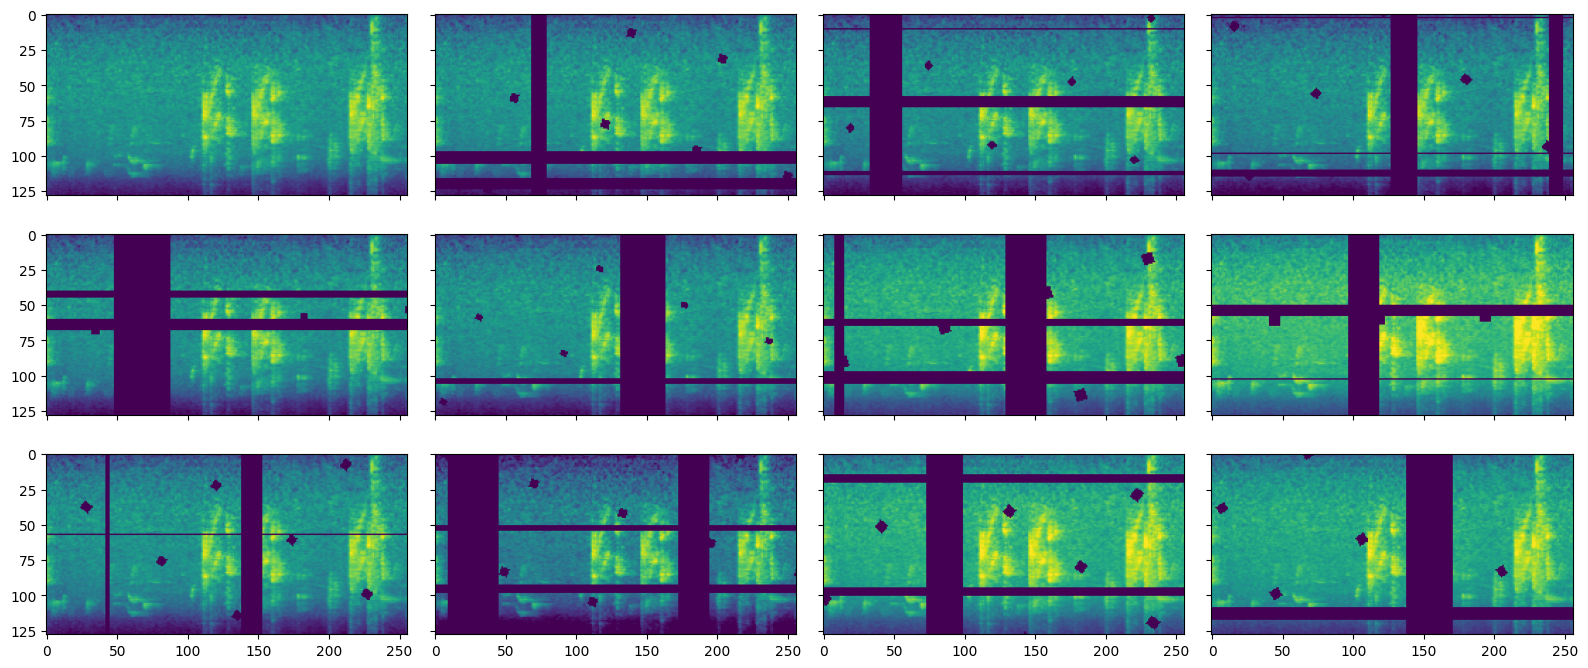

In [ ]:
img = read_image(rec.image_path)
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(16, 7))
for i, ax in enumerate(axs.flat):
    if i == 0:
        ax.imshow(img, cmap='viridis')
        show_img_stats(img)
    else:
        img1 = augmenter(img)
        ax.imshow(img1, cmap='viridis')
        show_img_stats(img1)
plt.tight_layout()
plt.show()

#### Check dataset

In [ ]:
dev_data = data.sample(500)
dev_ds = create_training_dataset(dev_data)
dev_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 667), dtype=tf.float32, name=None))>

In [ ]:
elem = next(iter(dev_ds.take(1)))
elem[1]

<tf.Tensor: shape=(64, 667), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

(TensorShape([128, 256, 1]), tf.float32, 8.449219, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 210.396)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 14.871357)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 242.46968)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 243.06335)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 230.21802)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 218.40527)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)


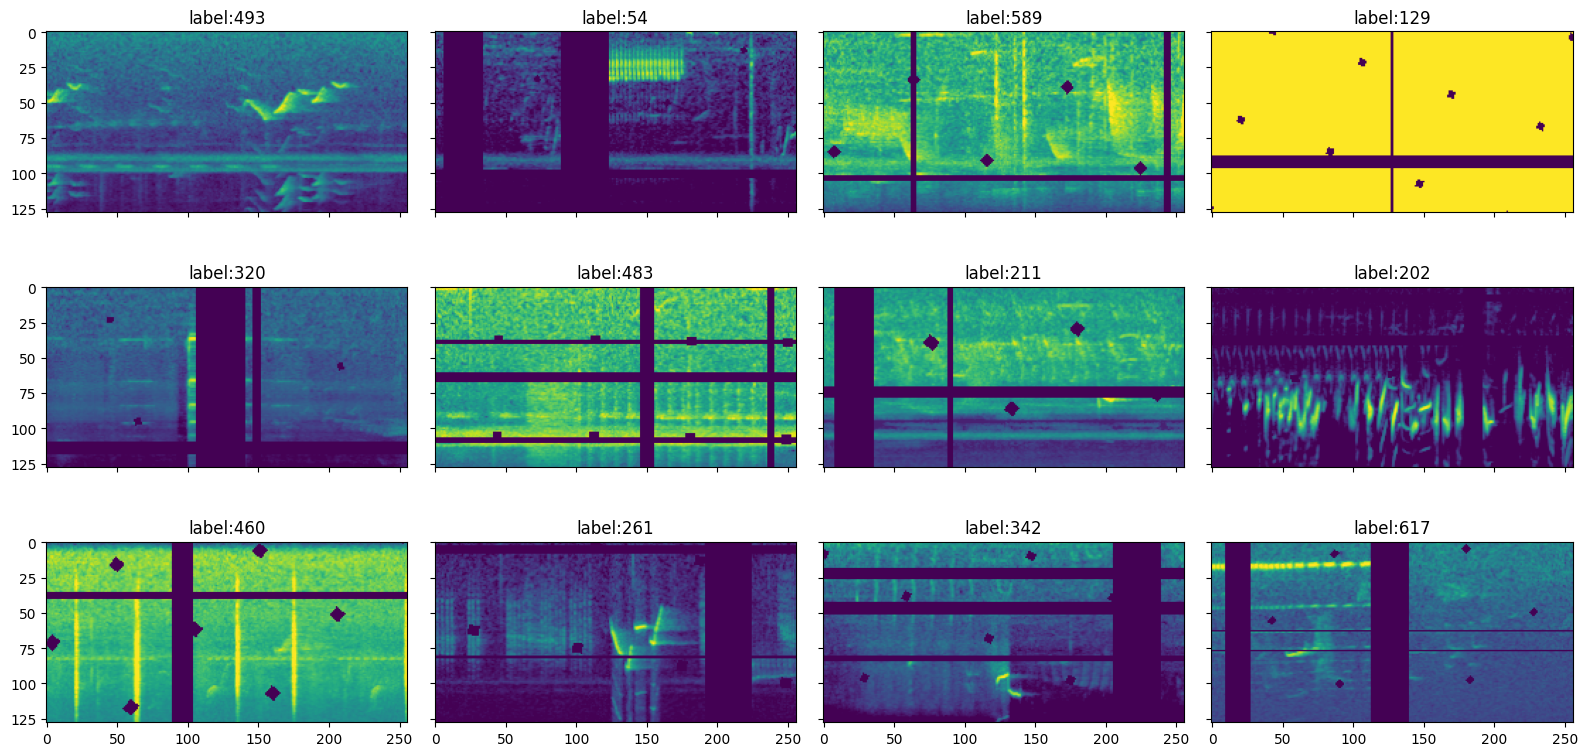

In [ ]:
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(16, 8))
for i, ax in enumerate(axs.flat):
    img = elem[0][i]
    show_img_stats(img)
    ax.imshow(img, cmap="viridis")
    ax.set_title(f"label:{np.argmax(elem[1][i].numpy())}")
plt.tight_layout()
plt.show()

# Neural network

In [ ]:
from tensorflow.keras.applications import ResNet152V2 as BaseModel
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras import layers, callbacks

In [ ]:
def create_model(lr, fine_tune_at=200):
    inputs = layers.Input(shape=cfg.img_shape, dtype=tf.float32, name="input_layer")
    x = layers.Lambda(lambda img: tf.image.grayscale_to_rgb(img))(inputs)
    x = layers.Lambda(preprocess_input, name="preprocess_input")(x)
    base_model = BaseModel(include_top=False, weights=cfg.base_model_weights, pooling="avg")
    base_model.trainable = True
    for layer in base_model.layers[:-fine_tune_at]:
        layer.trainable = False
    x = base_model(x)
    x = layers.Dropout(cfg.dropout, name="top_dropout")(x)
    outputs = layers.Dense(cfg.n_label, name="logits")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=cfg.model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.CategoricalCrossentropy(
            from_logits=True, label_smoothing=cfg.label_smoothing
        ),
        metrics=['acc']
    )

    return model

#### Check model

In [ ]:
import gc
gc.collect()
tf.keras.backend.clear_session()
with strategy.scope():
    dev_model = create_model(lr=cfg.lr)
dev_model.summary(line_length=120)

 64512000/234545216 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step

KeyboardInterrupt: 

In [ ]:
dev_model.predict(dev_ds.take(1))

In [ ]:
dev_model.evaluate(dev_ds.take(1), return_dict=True)

# Training utils

In [ ]:
def get_callbacks(filepath):
    """Get callbacks"""
    cbs = [
        callbacks.ModelCheckpoint(
            filepath=filepath,
            monitor=cfg.monitor,
            mode=cfg.monitor_mode,
            verbose=1,
            save_best_only=True,
            save_weights_only=True
        ),
        callbacks.EarlyStopping(
            monitor=cfg.monitor,
            mode=cfg.monitor_mode,
            verbose=1,
            patience=cfg.patience,
            restore_best_weights=False,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.1,
            patience=3,
            verbose=1,
            mode='min',
            min_lr=1e-7
            )
    ]
    return cbs


def show_history(history):
    """Show history"""
    history_frame = pd.DataFrame(history.history)
    history_frame.index = pd.RangeIndex(1, len(history_frame) + 1, name="epoch")
    display(history_frame.style\
        .highlight_min(color='lightgreen', subset=['val_loss'])\
        .highlight_max(color='lightgreen', subset=['val_acc'])
    )
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    history_frame.loc[:, ['loss', 'val_loss']].plot(ax=ax[0], title='loss')
    history_frame.loc[:, ['acc', 'val_acc']].plot(ax=ax[1], title='acc')
    plt.tight_layout()
    plt.show()


def compute_oof(model, valid_df):
    """Compute OOF"""
    valid_ds = create_validation_dataset(valid_df)
    oof_pred = model.predict(valid_ds, verbose=False)
    oof_pred = pd.DataFrame(tf.nn.sigmoid(oof_pred).numpy(), index=valid_df.index)
    oof = pd.concat({"y_true": valid_df[cfg.label], "y_pred": oof_pred}, axis=1)
    return oof

In [ ]:
def run_training(train_df, valid_df, model_name):
    """Run training"""
    # prepare dataset
    train_ds = create_training_dataset(train_df)
    valid_ds = create_validation_dataset(valid_df)
    # create model
    tf.keras.backend.clear_session()
    with strategy.scope():
        model = create_model(lr=cfg.lr)
    # fit
    steps_per_epoch = cfg.steps_per_epoch
    print("steps_per_epoch:", steps_per_epoch)
    path_weight = f"/content/drive/MyDrive/model/weights_{model_name}.weights.h5"
    print("path_weights:", path_weight)
    hist = model.fit(
        train_ds,
        epochs=cfg.epochs,
        steps_per_epoch=steps_per_epoch,
        validation_data=valid_ds,
        callbacks=get_callbacks(path_weight),
        verbose=cfg.fit_verbose
    )
    # restore
    model.load_weights(path_weight)
    oof = compute_oof(model, valid_df)
    return hist, oof,model

# Run training
Let us start by training just a single split.

In [ ]:
data['label'].value_counts()

In [ ]:
# seleccionar aleatoriamente 500 filas para las especies que superan las 500 muestras
df_sample = data.groupby('label').apply(lambda x: x.sample(500, random_state=42) if len(x) >500 else x).reset_index(drop=True)

In [ ]:
train_df, valid_df = train_test_split(df_sample, test_size=cfg.test_size, stratify=df_sample[cfg.label])
valid_df, test_df = train_test_split(valid_df, test_size=0.5, stratify=valid_df[cfg.label])
print(f"Split: {len(train_df)} vs {len(valid_df)} vs {len(test_df)}")
model_name = f"{cfg.model_name}"
print(f"model_name: {model_name}")

In [ ]:
train_df, valid_df = train_test_split(df_sample, test_size=cfg.test_size, stratify=df_sample[cfg.label])

value_counts = valid_df[cfg.label].value_counts()
classes_with_one_member = value_counts[value_counts == 1].index.tolist()

if classes_with_one_member:
    print(f"Warning: Removing classes with only 1 member from stratification: {classes_with_one_member}")
    mask = ~valid_df[cfg.label].isin(classes_with_one_member)
    valid_df, test_df = train_test_split(valid_df[mask], test_size=0.5, stratify=valid_df[mask][cfg.label])
    test_df = pd.concat([test_df, valid_df[~mask]])
    valid_df = valid_df[mask]
else:
    valid_df, test_df = train_test_split(valid_df, test_size=0.5, stratify=valid_df[cfg.label])

print(f"Split: {len(train_df)} vs {len(valid_df)} vs {len(test_df)}")
model_name = f"{cfg.model_name}"
print(f"model_name: {model_name}")

In [ ]:
classes_with_one_member

In [ ]:
test_df.head()

In [ ]:
test_df.info()

In [ ]:
%%time
hist, oof, model = run_training(train_df, valid_df, model_name)

In [ ]:
show_history(hist)

In [ ]:
oof.to_csv(f"/content/drive/MyDrive/transfer_learn_{cfg.model_name}.csv")

# Evaluation

In [ ]:
test_ds = create_validation_dataset(test_df)

In [ ]:
true_labels = []
i=0
test_ds_size = test_ds.cardinality().numpy()
print(test_ds_size)
for batch in test_ds:
    _, batch_labels = batch  # assuming that labels are the second element of the batch tuple
    true_labels.extend(batch_labels.numpy().tolist())
    i+=1

In [ ]:
pred_labels = model.predict(test_ds, verbose=cfg.fit_verbose)

In [ ]:
from sklearn.metrics import average_precision_score
mAP_score = average_precision_score(true_labels, pred_labels, average='macro')
average_precision = average_precision_score(true_labels, pred_labels)
print("Average Precision ", average_precision)
print("Macro average precision", mAP_score)

In [ ]:
from sklearn.metrics import accuracy_score
true_label = np.array(true_labels)
true_label = np.argmax(true_labels, axis=1)

pred_label=tf.argmax(pred_labels, axis=1).numpy()
# # assume y_true and y_pred are your true and predicted labels, respectively
acc = accuracy_score(true_label, pred_label)
print(acc)

In [ ]:
def decode_label(label):
    integer_encoded = label_encoder.transform(label)
    return tf.one_hot(integer_encoded, depth=cfg.n_label), integer_encoded

In [ ]:
_, tru_label = decode_label(data[cfg.label].values)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
precision = precision_score(true_label, pred_label, average='macro')
recall = recall_score(true_label, pred_label,  average='macro')
f1_score = f1_score(true_label, pred_label, average='macro')

print("Precision: ", precision)
print("Recall: ", recall)
print("F1_score: ", f1_score)

true_label_str = label_encoder.inverse_transform(true_label)
pred_label_str = label_encoder.inverse_transform(pred_label)

# classification_report
print(classification_report(true_label_str, pred_label_str))

In [ ]:
import pickle
with open(f"/content/drive/MyDrive/model/label_encoder_{model_name}.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [ ]:
test_df.to_csv(f"/content/drive/MyDrive/test_{model_name}.csv")

In [ ]:
from google.colab import runtime
runtime.unassign()